1. Дописать фильтрацию
2. Протестировать фильтрацию + отправить первый ответ с w2v
3. Заменить w2v на rubert или чет такое -> сравнить + попробовать еще модели
4. написать описание ноутбука и все оформить

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import pymorphy3
from nltk.corpus import stopwords

from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

from torch.utils.data import Dataset, DataLoader, random_split
import torch
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F

seed = 42

d:\projects\avito_retr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EDA (почти)

In [ ]:
train = pd.read_parquet('dataset/train.parquet')
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 497673 entries, 0 to 497672
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   search_query               497673 non-null  str    
 1   search_location_id         497673 non-null  int64  
 2   search_is_delivery_search  497673 non-null  int32  
 3   search_infm_params_text    497673 non-null  str    
 4   search_category            497673 non-null  int64  
 5   item_title_raw             497673 non-null  str    
 6   item_rating_reviews_count  478462 non-null  float64
 7   item_rating                469441 non-null  float64
 8   item_price                 497673 non-null  object 
 9   item_microcat_id           497673 non-null  int64  
 10  item_longitude             497669 non-null  object 
 11  item_location_id           497673 non-null  int64  
 12  item_latitude              497669 non-null  object 
 13  item_is_phone_hidden       497673 non-nu

### Items

In [101]:
train.head()

,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,...,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id,search_query_norm,item_title_norm
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.000000000000000,2303374,...,652430,54.629230499267578,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114,"[скупка, телевизор]","[скупка, б, техника]"
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.000000000000000,2303374,...,640860,56.273389999999999,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114,[автоподбор],"[автоподбор, разовый, осмотр, автомобиль]"
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.000000000000000,86469,...,653240,59.783687590000000,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114,"[баня, дрова]","[баня, дрова, прованс, цветочный]"
3,изготовление госномера на авто,634670,0,"Вид услуги Оборудование, производство",114,"Изготовление дубликатов авто номеров, гос номеров",14.0,4.714286,1700.000000000000000,2303428,...,633570,45.424875000000000,False,False,"Вид услуги Оборудование, производство Тип услу...",45b8628b9c6e7b85,Изготовим дубликат номера по утере или износу ...,114,"[изготовление, госномер, авто]","[изготовление, дубликат, авто, номер, гос, номер]"
4,укладка плитки,658430,0,Тип услуги Ремонт квартир и домов под ключ Вид...,114,Ремонт и отделка квартир под ключ,1.0,5.000000,1000.000000000000000,44725,...,658430,56.105983729999998,False,False,Вид услуги Ремонт и отделка Тип услуги Ремонт ...,c95a4a7daf2a967f,отделочные работы любой сложности.,114,"[укладка, плитка]","[ремонт, отделка, квартира, ключ]"


#### item_rating_reviews_count, item_rating_reviews_count

Mean:  88.59162901129034
Med:  25.0

Mean:  86.13688707243512
Med:  25.0


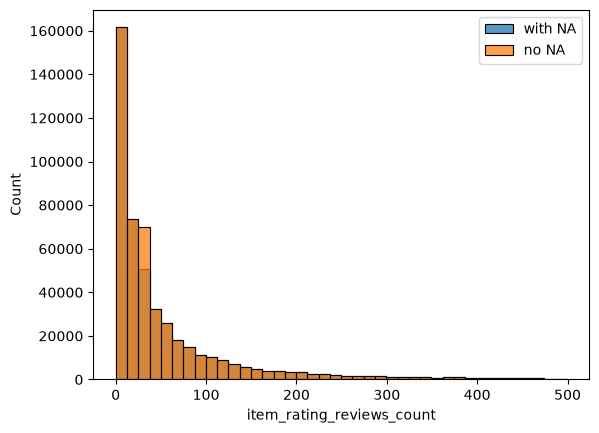

In [107]:
rating_revs = train['item_rating_reviews_count']
sns.histplot(rating_revs[rating_revs < 500], label='with NA', bins=40)
rating_revs_nona = rating_revs.fillna(rating_revs.median())
sns.histplot(rating_revs_nona[rating_revs_nona < 500], label='no NA', bins=40)
plt.legend()
print('Mean: ', rating_revs.mean())
print('Med: ', rating_revs.median())
print()
print('Mean: ', rating_revs_nona.mean())
print('Med: ', rating_revs_nona.median())


Огромный тяжелый хвост. Медианно - 16 ревью на статье, в среднем - 66 \
Просто так заменить nan на одно из этих значений - фигня (график это показывает). Все равно заменим на медиану, пока 

Mean:  4.816749691427982
Med:  5.0

Mean:  4.816749691427983
Med:  4.98804780876494


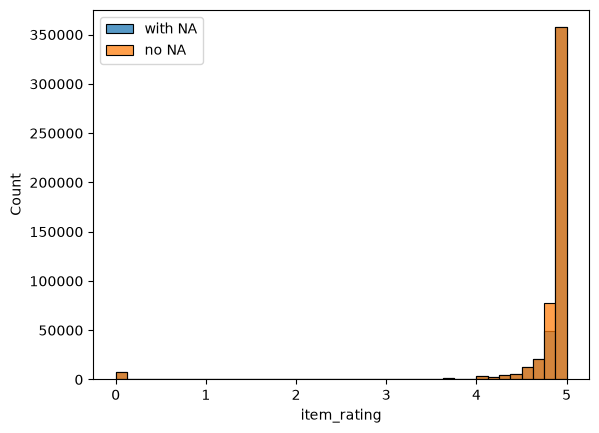

In [105]:
rating = train['item_rating']
sns.histplot(rating[rating > -1], label='with NA', bins=40)
rating_nona = rating.fillna(rating.mean())
sns.histplot(rating_nona[rating_nona > -1], label='no NA', bins=40)
plt.legend()
print('Mean: ', rating.mean())
print('Med: ', rating.median())
print()
print('Mean: ', rating_nona.mean())
print('Med: ', rating_nona.median())

Подавляющая часть рейтингов - сильно положительная. В целом это проблема многих приложений, например в такси я слышал, что если твой рейтинг ниже условных 4.7, то значит ты быдло. Ну я и сам скептично на этот рейтинг смотрю. Поэтому здесь можно просто дать среднее значение, будет вполне нормально.

Таких образом разобрались с "холодными" объявлениями -- избавились от пропусков, но в обучении все равно надо в лоссе это учесть

#### item_is_phone_hidden, item_is_message_forbidden

([<matplotlib.axis.XTick at 0x2a3d0a409d0>,
 [Text(0, 0, 'False'), Text(1, 0, 'True')])

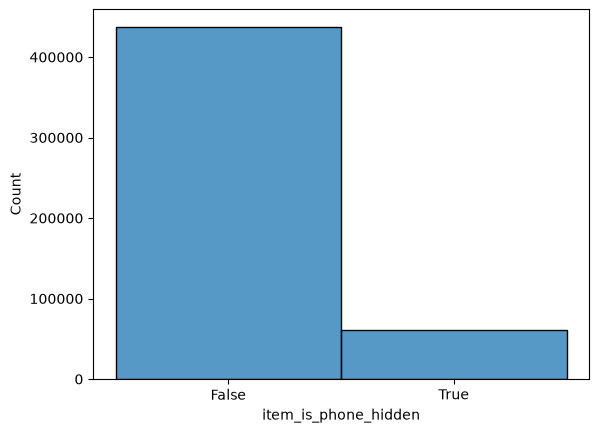

In [108]:
sns.histplot(train['item_is_phone_hidden'], discrete=True)
plt.xticks([0, 1], ['False', 'True'])

([<matplotlib.axis.XTick at 0x2a3d09d2050>,
 [Text(0, 0, 'False'), Text(1, 0, 'True')])

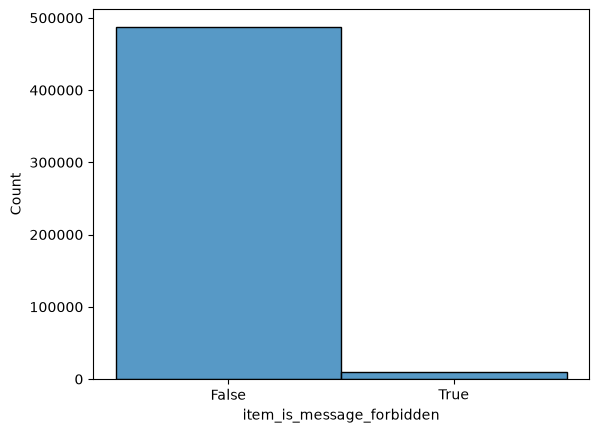

In [109]:
sns.histplot(train['item_is_message_forbidden'], discrete=True)
plt.xticks([0, 1], ['False', 'True'])

#### item_price

<Axes: xlabel='item_price', ylabel='Count'>

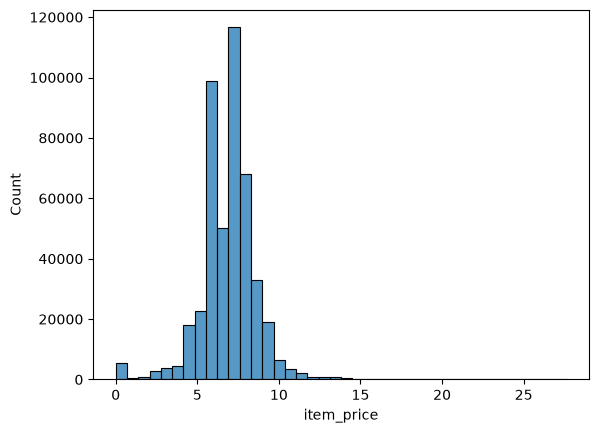

In [139]:
x = train['item_price'].astype(float).apply(np.log)
sns.histplot(x, bins=40)

### Query

In [44]:
train.head()

,search_query,search_location_id,search_is_delivery_search,search_infm_params_text,search_category,item_title_raw,item_rating_reviews_count,item_rating,item_price,item_microcat_id,item_longitude,item_location_id,item_latitude,item_is_phone_hidden,item_is_message_forbidden,item_infm_params_text,item_id,item_description_raw,item_category_id
0,скупка телевизоров,652430,0,,114,Скупка б/у техники,91.0,4.989011,1.000000000000000,2303374,39.712818145751953,652430,54.629230499267578,True,False,Вид услуги Место оказания услуг Первомайский п...,e8b685dffe1a408e,Скупаю практически любую современную новую и б...,114
1,автоподбор,640860,0,Рейтинг пользователя 4 звезды и выше,114,Автоподбор Разовый осмотр автомобиля,462.0,4.982684,3500.000000000000000,2303374,44.051009999999998,640860,56.273389999999999,False,False,Вид услуги Место оказания услуг Нижний Новгоро...,92e1b0446f827b59,🚗 Автоподбор и выездная диагностика автомобиля...,114
2,баня на дровах,653240,0,"Онлайн-запись Тип услуги СПА-услуги, массаж Ви...",114,"Баня на дровах ""Прованс"" на Цветочной",NaN,NaN,1600.000000000000000,86469,30.128784180000000,653240,59.783687590000000,False,False,"Вид услуги Красота, здоровье Место оказания ус...",624846856ce81d69,В ритме современной жизни так сложно найти мо...,114
3,изготовление госномера на авто,634670,0,"Вид услуги Оборудование, производство",114,"Изготовление дубликатов авто номеров, гос номеров",14.0,4.714286,1700.000000000000000,2303428,40.537841000000000,633570,45.424875000000000,False,False,"Вид услуги Оборудование, производство Тип услу...",45b8628b9c6e7b85,Изготовим дубликат номера по утере или износу ...,114
4,укладка плитки,658430,0,Тип услуги Ремонт квартир и домов под ключ Вид...,114,Ремонт и отделка квартир под ключ,1.0,5.000000,1000.000000000000000,44725,69.496444699999998,658430,56.105983729999998,False,False,Вид услуги Ремонт и отделка Тип услуги Ремонт ...,c95a4a7daf2a967f,отделочные работы любой сложности.,114


#### item_id

<Axes: xlabel='count', ylabel='Count'>

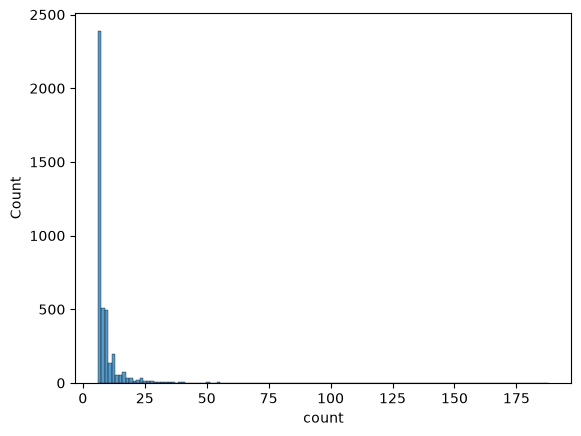

In [8]:
# train['item_id'].value_counts()
id_count = train['item_id'].value_counts()
sns.histplot(id_count[id_count > 5])

#### search_location_id vs item_location_id

In [41]:
num_eq = train[train['search_location_id'] == train['item_location_id']].shape[0]
num_all = train.shape[0]
print(num_eq/num_all)

0.8310195650557696


в 83% локация item совпадает с локацией запроса. Можно использовать как фильтр

#### item_is_phone_hidden, item_is_message_forbidden

([<matplotlib.axis.XTick at 0x12a5c933790>,
 [Text(0, 0, 'False'), Text(1, 0, 'True')])

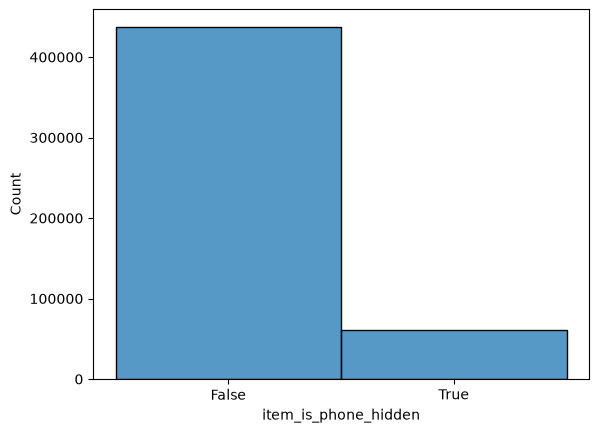

In [42]:
sns.histplot(train['item_is_phone_hidden'], discrete=True)
plt.xticks([0, 1], ['False', 'True'])

([<matplotlib.axis.XTick at 0x12a5c8deed0>,
 [Text(0, 0, 'False'), Text(1, 0, 'True')])

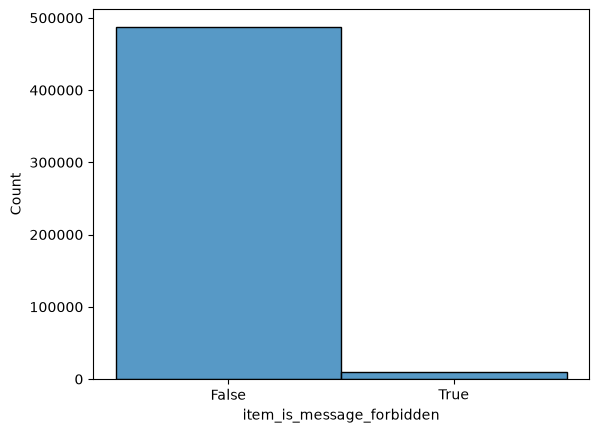

In [43]:
sns.histplot(train['item_is_message_forbidden'], discrete=True)
plt.xticks([0, 1], ['False', 'True'])

Если бы был перекос сильнее в сторону False, то в общем случае был бы сигнал о том, что это сильно влияет, но в общем случае, видимо, не влияет. Лучше бы проверил детальнее

#### search_infm_params_text vs item_infm_params_text

Сходил на сайт авито. Тип - только один может быть. Вид, кажется, тоже (вопрос к Красота, здоровье: не справился выбрать одновременно 2 -- видимо это старые данные, сайт поменялся) \
То что все через пробел просто это мрак, кто так вообще данные сдает

Предобработка этого момента в data prepare \
Выделим только тип услуги и вид услуги. Создадим новые колонки, которые будут эти 2 паттерна показывать. Также избавимся от мусора в item, потому что если не заполнено поле у пользователя, то там априоре мусор, который после фильтрации item не будет показываться.

## Data preprocess

### Полный код

In [5]:
# надо запустить
targets = ["Вид услуги", "Тип услуги",]
queries_renames = {"вид услуги": "search_vid_services", "тип услуги": "search_type_services"}
items_renames = {"вид услуги": "item_vid_services", "тип услуги": "item_type_services"}

def parse_params(text, targets):
    parts = re.split(r'\s+(?=[А-Я])', text)
    idxs = {k: parts.index(k) 
            if k in parts else None 
            for k in targets }

    for k, v in idxs.items():
        if v == len(parts) - 1:
            idxs[k] = None

    result = {k.strip().lower(): parts[idx + 1].strip().lower() 
              if idx != None else None 
              for k, idx in idxs.items() }    

    return result

def extract_params(df, column, targets, renames):
    df[column] = df[column].apply(parse_params, targets=targets)
    df_expanded = pd.json_normalize(df[column]).rename(columns=renames)
    df = pd.concat([df.drop(column, axis=1), df_expanded], axis=1)
    return df

morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words("russian"))

def preprocess(df, column):
    def preprocess_(text):
        text = str(text).lower()
        words = re.findall(r"[a-zа-яё0-9]+", text)
        result = []
        for word in words:
            if word in stop_words:
                continue
            lemma = morph.parse(word)[0].normal_form
            if lemma not in stop_words:
                result.append(lemma)
        if len(result) == 0:
            return words
        return result

    norm_df = df[column].apply(preprocess_)
    df[f'{column}_norm'] = norm_df
    return df


In [6]:
# надо запустить
train = pd.read_parquet('dataset/train.parquet')
item_cols = train.columns[train.columns.str.startswith('item')]
queries_df = train.drop(columns=item_cols)
queries_df['item_id'] = train['item_id']
items_df = train[item_cols]
items_df = items_df.drop_duplicates(subset=['item_id'])

queries_df = extract_params(queries_df, 
                            column='search_infm_params_text', 
                            targets=targets, 
                            renames=queries_renames)
items_df = extract_params(items_df, 
                          column='item_infm_params_text', 
                          targets=targets, 
                          renames=items_renames)

# костыль для очистки пустых типов
x = items_df['item_vid_services']
bad_classes = list(x[x.str.startswith('место', na=False)].unique())
items_df['item_vid_services'] = items_df['item_vid_services'].replace(bad_classes, np.nan).str.strip()

x = items_df['item_type_services']
bad_classes = list(x[(x.str.startswith('место', na=False) | 
    x.str.startswith('районы', na=False) | 
    x.str.startswith('тип', na=False) | 
    x.str.startswith('куда', na=False) | 
    x.str.startswith('онлайн-показ', na=False) |
    x.str.startswith('начальная цена', na=False))].unique())
items_df['item_type_services'] = items_df['item_type_services'].replace(bad_classes, np.nan).str.strip()

queries_df = preprocess(queries_df, column='search_query')
items_df = preprocess(items_df, column='item_title_raw')

items_df['item_rating_reviews_count'] = items_df['item_rating_reviews_count'].fillna(items_df['item_rating_reviews_count'].median())
items_df['item_rating'] = items_df['item_rating'].fillna(items_df['item_rating'].mean())

In [7]:
# надо запустить
queries_df.to_parquet('preprocessed/train_queries.parquet', index=False)
items_df.to_parquet('preprocessed/train_items.parquet', index=False)

### Последовательно (с кратким описанием)

Сначала надо разделить табличку на items и queries, потому что дальше они иногда будут идти раздельно + хранить их так будет удобнее и места меньше заниматься (дублирование items)

In [ ]:
item_cols = train.columns[train.columns.str.startswith('item')]
queries_df = train.drop(columns=item_cols)
queries_df['item_id'] = train['item_id']
items_df = train[item_cols]
items_df = items_df.drop_duplicates(subset=['item_id'])

#### search + item filters

Выделение тегов, использованных при фильтрации

In [ ]:
targets = ["Вид услуги", "Тип услуги",]
queries_renames = {"вид услуги": "search_vid_services", "тип услуги": "search_type_services"}
items_renames = {"вид услуги": "item_vid_services", "тип услуги": "item_type_services"}

def parse_params(text, targets):
    parts = re.split(r'\s+(?=[А-Я])', text)
    idxs = {k: parts.index(k) 
            if k in parts else None 
            for k in targets }

    for k, v in idxs.items():
        if v == len(parts) - 1:
            idxs[k] = None

    result = {k.strip().lower(): parts[idx + 1].strip().lower() 
              if idx != None else None 
              for k, idx in idxs.items() }    

    return result

def extract_params(df, column, targets, renames):
    df[column] = df[column].apply(parse_params, targets=targets)
    df_expanded = pd.json_normalize(df[column]).rename(columns=renames)
    df = pd.concat([df.drop(column, axis=1), df_expanded], axis=1)
    return df


queries_df = extract_params(queries_df, 
                            column='search_infm_params_text', 
                            targets=targets, 
                            renames=queries_renames)
items_df = extract_params(items_df, 
                          column='item_infm_params_text', 
                          targets=targets, 
                          renames=items_renames)

In [ ]:
# костыль для очистки пустых типов
x = items_df['item_vid_services']
bad_classes = list(x[x.str.startswith('место', na=False)].unique())
items_df['item_vid_services'] = items_df['item_vid_services'].replace(bad_classes, np.nan).str.strip()

x = items_df['item_type_services']
bad_classes = list(x[(x.str.startswith('место', na=False) | 
    x.str.startswith('районы', na=False) | 
    x.str.startswith('тип', na=False) | 
    x.str.startswith('куда', na=False) | 
    x.str.startswith('онлайн-показ', na=False) |
    x.str.startswith('начальная цена', na=False))].unique())
items_df['item_type_services'] = items_df['item_type_services'].replace(bad_classes, np.nan).str.strip()

##### Черновик

In [ ]:
targets = [
    "Вид услуги",
    "Тип услуги",
]

def parse_params(text):
    parts = re.split(r'\s+(?=[А-Я])', text)
    idxs = {k: parts.index(k) 
            if k in parts else None 
            for k in targets }

    for k, v in idxs.items():
        if v == len(parts) - 1:
            idxs[k] = None

    result = {k.strip().lower(): parts[idx + 1].strip().lower() 
              if idx != None else None 
              for k, idx in idxs.items() }    

    return result


# idx = 0
# print(train['item_infm_params_text'][idx])
# print(parse_params(train['item_infm_params_text'][idx]))
# print(train['search_infm_params_text'][idx])
# print(parse_params(train['search_infm_params_text'][idx]))

In [4]:
# выделение паттернов из серча
train['search_infm_params_text'] = train['search_infm_params_text'].apply(parse_params)
train_expanded = pd.json_normalize(train['search_infm_params_text']).rename(columns={"вид услуги": "search_vid_services", "тип услуги": "search_type_services"})
train = pd.concat([train.drop('search_infm_params_text', axis=1), train_expanded], axis=1)

# выделение паттернов из item
train['item_infm_params_text'] = train['item_infm_params_text'].apply(parse_params)
train_expanded = pd.json_normalize(train['item_infm_params_text']).rename(columns={"вид услуги": "item_vid_services", "тип услуги": "item_type_services"})
train = pd.concat([train.drop('item_infm_params_text', axis=1), train_expanded], axis=1)

In [ ]:
# костыль для очистки пустых типов
x = train['item_vid_services']
bad_classes = list(x[x.str.startswith('место', na=False)].unique())
train['item_vid_services'] = train['item_vid_services'].replace(bad_classes, np.nan).str.strip()

x = train['item_type_services']
bad_classes = list(x[(x.str.startswith('место', na=False) | 
    x.str.startswith('районы', na=False) | 
    x.str.startswith('тип', na=False) | 
    x.str.startswith('куда', na=False) | 
    x.str.startswith('онлайн-показ', na=False) |
    x.str.startswith('начальная цена', na=False))].unique())
train['item_type_services'] = train['item_type_services'].replace(bad_classes, np.nan).str.strip()

#### norm titles

Нормализация текста для w2v - приведение к нормальной форме + удаление артифактов

In [ ]:
# тут есть ошибка и drop, в оригинале убрал

# morph = pymorphy3.MorphAnalyzer()
# stop_words = set(stopwords.words("russian"))

# def preprocess(df, column):
#     def preprocess_(text):
#         text = str(text).lower()
#         words = re.findall(r"[a-zа-яё0-9]+", text)
#         result = []
#         for word in words:
#             if word in stop_words:
#                 continue
#             lemma = morph.parse(word)[0].normal_form
#             if lemma not in stop_words:
#                 result.append(lemma)
#         return result

#     norm_df = df[column].apply(preprocess_)
#     df[f'{column}_norm'] = norm_df
#     x = list(df[f'{column}_norm'].apply(len))
#     df = df.drop(x).reset_index(drop=True)
#     return df

# queries_df = preprocess(queries_df, column='search_query')
# items_df = preprocess(items_df, column='item_title_raw')

##### Черновик

In [ ]:
morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words("russian"))

def preprocess_(text):
    text = str(text).lower()
    words = re.findall(r"[a-zа-яё0-9]+", text)
    result = []
    for word in words:
        if word in stop_words:
            continue
        lemma = morph.parse(word)[0].normal_form
        if lemma not in stop_words:
            result.append(lemma)
    return result

In [8]:
norm_q = train['search_query'].apply(preprocess)
norm_i = train['item_title_raw'].apply(preprocess)
train['search_query_norm'] = norm_q
train['item_title_norm'] = norm_i

In [9]:
x = train['search_query_norm'].apply(len)
y = train['item_title_norm'].apply(len)
drop_indx = list(set(y[y == 0].index).union(set(x[x == 0].index)))

In [10]:
train = train.drop(drop_indx).reset_index(drop=True)

#### fill na vals

Заполнение пустых значений рейтингов медианным и средним значением

In [ ]:
items_df['item_rating_reviews_count'] = items_df['item_rating_reviews_count'].fillna(items_df['item_rating_reviews_count'].median())
items_df['item_rating'] = items_df['item_rating'].fillna(items_df['item_rating'].mean())

##### Черновик

In [ ]:
# Втупую
train['item_rating_reviews_count'] = train['item_rating_reviews_count'].fillna(train['item_rating_reviews_count'].median())
train['item_rating'] = train['item_rating'].fillna(train['item_rating'].mean())

#### save

In [ ]:
queries_df.to_parquet('dataset/train_queries.parquet', index=False)
items_df.to_parquet('dataset/train_items.parquet', index=False)

##### Черновик

In [ ]:
train.to_parquet('dataset/train_preprocces.parquet', index=False)

In [19]:
item_cols = train.columns[train.columns.str.startswith('item')]
queries_df = train.drop(columns=item_cols)
queries_df['item_id'] = train['item_id']
items_df = train[item_cols]
items_df = items_df.drop_duplicates(subset=['item_id'])

In [ ]:
queries_df.to_parquet('dataset/train_queries.parquet', index=False)
items_df.to_parquet('dataset/train_items.parquet', index=False)

## Dataset + Eval Func

выделил основные численные признаки, скипнул описание и тд: \
use:
1. search_query
2. item_title_raw             
3. item_rating_reviews_count  
4. item_rating
5. item_price                 
6. item_is_phone_hidden       
7. item_is_message_forbidden  

skip:
1. search_is_delivery_search  
2. item_microcat_id
3. item_description_raw     
4. item_longitude             
5. item_latitude              

фильтрация на инференсе
1. search_infm_params_text <--> item_infm_params_text
2. search_location_id <--> item_location_id
3. search_category <--> item_category_id

Создаем 2 датасета: 1 общий на train и val - items, 2 - для запросов. Будем хранить то, что указано выше + заранее обрабатывать текст, чтобы экономить вреямя на train \
Также пропишем логику для hf трансформера и w2v заранее

In [16]:
# надо запустить

class ItemDataset(Dataset):
    def __init__(self, model, items_df):
        super().__init__()
        self.embedder = model

        item_phone_hidden = torch.from_numpy(items_df[['item_is_phone_hidden', 'item_is_message_forbidden']].to_numpy().astype(np.float32))
        item_price = torch.from_numpy(items_df['item_price'].to_numpy().astype(np.float32)).unsqueeze(-1)
        item_rating = torch.from_numpy(items_df['item_rating'].to_numpy().astype(np.float32)).unsqueeze(-1)
        item_rating_reviews_count = torch.from_numpy(items_df['item_rating_reviews_count'].to_numpy().astype(np.float32)).unsqueeze(-1)
        self.context = torch.cat([item_phone_hidden, item_price, item_rating, item_rating_reviews_count], dim=1)

        self.item_emb = self.prepare_embeddings(items_df, 'item_title_raw_norm')
        self.item_id_to_idx = {item_id: idx
                          for idx, item_id in enumerate(items_df['item_id'])}
        self.item_ids = items_df['item_id'].to_numpy()

        vids = items_df['item_vid_services'].fillna('UNK')
        # выставить unk на первое место, чтобы дальше не было багов
        values = ['UNK'] + [x for x in vids.unique() if x != 'UNK']
        self.str_to_id = {s: i for i, s in enumerate(values)}
        self.id_to_str = {i: s for i, s in enumerate(values)}
        self.item_category = torch.from_numpy(vids.map(self.str_to_id).to_numpy().astype(np.int32))

        self.item_location_id = torch.from_numpy(items_df['item_location_id'].to_numpy().astype(np.int32))

    def prepare_embeddings(self, df, col):
        data = df[col].to_list()
        if isinstance(self.embedder, SentenceTransformer):
            print('Use SentenceTransformer')
            embeddings = self.embedder.encode(data, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
            return embeddings
        else:
            print('Use Word2Vec')
            res_vecs = []
            for i in tqdm(range(len(data)), desc=col):
                indices_matrix = [self.embedder.get_index(word, default=0) for word in data[i]] 
                vectors = self.embedder.vectors[indices_matrix]
                res_vec = np.mean(vectors, axis=0)
                res_vecs.append(res_vec)
            return torch.from_numpy(np.array(res_vecs).astype(np.float32))

    def __len__(self):
        return self.item_emb.shape[0]

    def __getitem__(self, idx):
        return (self.item_emb[idx], self.context[idx], self.item_location_id[idx], self.item_category[idx])


class QueriesDataset(Dataset):
    def __init__(self, queries_df, item_dataset, mode='train'):
        super().__init__()
        self.mode = mode
        self.embedder = item_dataset.embedder
        self.item_dataset = item_dataset
        self.q_emb = self.prepare_embeddings(queries_df, 'search_query_norm')

        # связываем 2 таблицы
        if self.mode == 'train':
            self.query_item_idx = torch.tensor(
                [
                    self.item_dataset.item_id_to_idx[item_id]
                    for item_id in queries_df['item_id']
                ],
                dtype=torch.long
            )
        vids = queries_df['search_vid_services'].fillna('UNK')
        self.query_category = torch.from_numpy(vids.map(self.item_dataset.str_to_id).to_numpy().astype(np.int32))
        self.query_location_id = torch.from_numpy(queries_df['search_location_id'].to_numpy().astype(np.int32))
        
    def prepare_embeddings(self, df, col):
        data = df[col].to_list()
        if isinstance(self.embedder, SentenceTransformer):
            embeddings = self.embedder.encode(data, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
            return embeddings
        else:
            res_vecs = []
            for i in tqdm(range(len(data)), desc=col):
                indices_matrix = [self.embedder.get_index(word, default=0) for word in data[i]] 
                vectors = self.embedder.vectors[indices_matrix]
                res_vec = np.mean(vectors, axis=0)
                res_vecs.append(res_vec)
            return torch.from_numpy(np.array(res_vecs).astype(np.float32))

    def __len__(self, ):
        return self.q_emb.shape[0]

    def __getitem__(self, idx):
        if self.mode == 'train':
            item_idx = self.query_item_idx[idx]
            item_emb, context, _, _ = self.item_dataset[item_idx]
            return (
                self.q_emb[idx], 
                item_emb, 
                context, 
                item_idx,
                self.query_location_id[idx],
                self.query_category[idx],
            )
        elif self.mode == 'test':
            return (
                    self.q_emb[idx],
                    self.query_location_id[idx],
                    self.query_category[idx],
                )

In [5]:
# надо запустить

def get_device():
    device = "cpu"
    if torch.cuda.is_available():
        device="cuda:0"
    return device


def evaluate(queries_dataset, items_dataset, model, device, k=50, filters=True):
    model.eval()
    item_dataloader = DataLoader(dataset=items_dataset,
                                 batch_size=1024,
                                 num_workers=0,
                                 shuffle=False)
    queries_dataloader = DataLoader(dataset=queries_dataset,
                                    batch_size=64,
                                    num_workers=0,
                                    shuffle=False)
    i_embeddings = []
    with torch.no_grad():
        for batch in tqdm(item_dataloader, desc='Items'):
            i_emb, context, _, _ = batch
            i_emb = i_emb.to(device)
            context = context.to(device)
            i = model.get_i_tower_emb((i_emb, context))
            i_embeddings.append(i)

    item_location_id = items_dataset.item_location_id
    item_category = items_dataset.item_category
    i_embeddings = torch.cat(i_embeddings, dim=0)
    item_ids = torch.arange(0, len(items_dataset.item_ids))

    hits = 0
    # ndcg_sum = 0
    n_queries = 0
    ans = []
    with torch.no_grad():
        for batch in tqdm(queries_dataloader, desc='Queries'):
            if queries_dataset.mode == 'train':
                q_emb, _, _, real_item_idx, query_location_id, query_category = batch
            elif queries_dataset.mode == 'test':
                q_emb, query_location_id, query_category = batch
            q_emb = q_emb.to(device)
            q = model.get_q_tower_emb(q_emb)
            scores = q @ i_embeddings.T

            if filters:
                # # маска локации
                location_mask = (query_location_id[:, None] == item_location_id[None, :]).to(device)
                # маска вида услуги
                category_mask = ((query_category[:, None] == 0) | (query_category[:, None] == item_category[None, :])).to(device)
                # общая маска
                valid_mask = location_mask & category_mask
                # наложение маски
                scores = scores.masked_fill(~valid_mask, -torch.inf)

            _, top_indices = torch.topk(scores, k=k, dim=1)

            top_ids = item_ids[top_indices.cpu()]
            if queries_dataset.mode == 'train':
                matches = top_ids == real_item_idx[:, None]

                hit = matches.any(dim=1)
                hits += hit.sum().item()
                n_queries += len(real_item_idx)
            ans.append(top_ids)

    if queries_dataset.mode == 'train':       
        recall = hits / n_queries
        return {f'Recall@{k}': recall,}
    elif queries_dataset.mode == 'test':
        return ans

## Two tower + W2V

### Загрузка данных

In [10]:
# запустить после препроцесса

queries_df = pd.read_parquet('preprocessed/train_queries.parquet')
items_df = pd.read_parquet('preprocessed/train_items.parquet')

### W2V train

In [11]:
# запустить после препроцесса

item_corpus = items_df['item_title_raw_norm']
query_corpus = queries_df['search_query_norm']

sentences = pd.concat([
    query_corpus,
    item_corpus
]).tolist()
sentences = [w.tolist() for w in sentences]

In [12]:
# # запустить после препроцесса

vec_size = 128
w2v = Word2Vec(
    sentences=sentences,
    vector_size=vec_size,
    window=5,
    min_count=2,
    sg=1,
    negative=10,
    workers=8,
    epochs=10
)

w2v.save(f'models/w2v/word2vec_{vec_size}.model')

### Модель

In [13]:
class ITower(nn.Module):
    def __init__(self):
        super(ITower, self).__init__()
        self.context_proj = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Linear(64, 128), 
            nn.ReLU()
        )

        self.dense = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

    def forward(self, data):
        i_emb, i_context = data
        i_context_emb = self.context_proj(i_context)
        x = torch.cat((i_emb, i_context_emb), dim=1)
        i_tower_emb = self.dense(x)
        return i_tower_emb


class QTower(nn.Module):
    def __init__(self):
        super(QTower, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

    def forward(self, q_emb):
        q_tower_emb = self.dense(q_emb)
        return q_tower_emb


class TwoTower(nn.Module):
    def __init__(self):
        super(TwoTower, self).__init__()
        self.q_tower = QTower()
        self.i_tower = ITower()

    def get_q_tower_emb(self, q_emb):
        q_tower_emb = self.q_tower(q_emb)
        q = F.normalize(q_tower_emb, dim=-1)
        return q

    def get_i_tower_emb(self, data):
        i_emb, context = data
        i_tower_emb = self.i_tower((i_emb, context))
        i = F.normalize(i_tower_emb, dim=-1)
        return i
    
    def forward(self, data):
        q_emb, i_emb, context = data
        q = self.get_q_tower_emb(q_emb)
        i = self.get_i_tower_emb((i_emb, context))
        return q, i

### Train

In [14]:
# если есть уже обученый w2v

queries_df = pd.read_parquet('preprocessed/train_queries.parquet')
items_df = pd.read_parquet('preprocessed/train_items.parquet')
w2v = Word2Vec.load('models/w2v/word2vec_128.model')

In [ ]:
g = torch.Generator()
g.manual_seed(seed)

item_dataset = ItemDataset(w2v.wv, items_df=items_df)

train_df, val_df = train_test_split(queries_df, test_size=0.1, random_state=seed)
train_dataset = QueriesDataset(queries_df=train_df, item_dataset=item_dataset)
val_dataset = QueriesDataset(queries_df=val_df, item_dataset=item_dataset, mode='train')
train_dataloader = DataLoader(train_dataset, 
                              num_workers=0, 
                              shuffle=True, 
                              batch_size=1024,
                              generator=g)

search_query_norm: 100%|██████████| 49768/49768 [00:00<00:00, 75849.16it/s]


In [16]:
model = TwoTower()

Для обучения in-batch negative sampling

In [ ]:
device = get_device()
model.to(device)
optimizer = torch.optim.Adam(model.parameters())

temperature = 0.1
n_epochs = 10
batches_per_epoch = 300

for epoch in range(n_epochs):
    model.train()   
    batch_iter = iter(train_dataloader)
    pbar = tqdm(range(batches_per_epoch))
    loss_sum = 0
    for batch_idx in pbar:
        q_emb, i_emb, context, item_ids, _, _ = [tensor.to(device) for tensor in next(batch_iter)]
        
        q, i = model((q_emb, i_emb, context))
        logits = (q @ i.T) / temperature
        
        same_item = item_ids[:, None] == item_ids[None, :]
        diag = torch.arange(logits.size(0), device=device)
        same_item[diag, diag] = False

        logits[same_item] = -torch.inf
        targets = torch.arange(logits.size(0), device=device)
        loss = F.cross_entropy(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        pbar.set_description(f"Epoch {epoch} --- loss: {loss_sum / (batch_idx + 1)} | ")

    # recall = evaluate(queries_dataset=val_dataset, items_dataset=item_dataset, model=model, device=device, k=100)
    # print(f'Recall@100: {recall}')

Epoch 0 --- loss: 5.048016262849172 | : 100%|██████████| 300/300 [00:16<00:00, 18.03it/s] 
Epoch 1 --- loss: 2.8030730414390566 | : 100%|██████████| 300/300 [00:11<00:00, 25.08it/s]
Epoch 2 --- loss: 2.6343454273541766 | : 100%|██████████| 300/300 [00:12<00:00, 24.59it/s]
Epoch 3 --- loss: 2.5749814168612164 | : 100%|██████████| 300/300 [00:12<00:00, 24.90it/s]
Epoch 4 --- loss: 2.5376345340410866 | : 100%|██████████| 300/300 [00:11<00:00, 25.25it/s]
Epoch 5 --- loss: 2.5178629676500957 | : 100%|██████████| 300/300 [00:12<00:00, 24.82it/s]
Epoch 6 --- loss: 2.4888312451044716 | : 100%|██████████| 300/300 [00:12<00:00, 24.97it/s]
Epoch 7 --- loss: 2.4706141169865927 | : 100%|██████████| 300/300 [00:12<00:00, 24.98it/s]
Epoch 8 --- loss: 2.459686979452769 | : 100%|██████████| 300/300 [00:12<00:00, 24.40it/s] 
Epoch 9 --- loss: 2.4481748898824054 | : 100%|██████████| 300/300 [00:12<00:00, 24.89it/s]


In [18]:
recall = evaluate(queries_dataset=val_dataset, items_dataset=item_dataset, model=model, device=device, k=50, filters=False)
recall_filtered = evaluate(queries_dataset=val_dataset, items_dataset=item_dataset, model=model, device=device, k=50, filters=True)

Queries: 100%|██████████| 778/778 [00:29<00:00, 25.94it/s]


In [20]:
print(recall)
print(recall_filtered)

{'Recall@50': 0.11961501366339816}
{'Recall@50': 0.7497588812088088}


In [22]:
torch.save(model.state_dict(), "models/w2v/two_tower_w2v_128.pth")

Фильтры сильно зарешали, но использованы они топорно, от чего качество ограничено. Надо было менее жестко отсекать кондидатов

### Gen Ans

In [23]:
queries_df_test = pd.read_parquet('dataset/benchmark_queries.parquet')
items_df_test = pd.read_parquet('dataset/benchmark_items.parquet')

targets = ["Вид услуги", "Тип услуги",]
queries_renames = {"вид услуги": "search_vid_services", "тип услуги": "search_type_services"}
items_renames = {"вид услуги": "item_vid_services", "тип услуги": "item_type_services"}

queries_df_test = extract_params(queries_df_test, 
                            column='search_infm_params_text', 
                            targets=targets, 
                            renames=queries_renames)
items_df_test = extract_params(items_df_test, 
                          column='item_infm_params_text', 
                          targets=targets, 
                          renames=items_renames)
print('Экстракция')

x = items_df_test['item_vid_services']
bad_classes = list(x[x.str.startswith('место', na=False)].unique())
items_df_test['item_vid_services'] = items_df_test['item_vid_services'].replace(bad_classes, np.nan).str.strip()
x = items_df_test['item_type_services']
bad_classes = list(x[(x.str.startswith('место', na=False) | 
    x.str.startswith('районы', na=False) | 
    x.str.startswith('тип', na=False) | 
    x.str.startswith('куда', na=False) | 
    x.str.startswith('онлайн-показ', na=False) |
    x.str.startswith('начальная цена', na=False))].unique())
items_df_test['item_type_services'] = items_df_test['item_type_services'].replace(bad_classes, np.nan).str.strip()
print('Костыль')

queries_df_test = preprocess(queries_df_test, column='search_query')
items_df_test = preprocess(items_df_test, column='item_title_raw')
print('Нормализация')

items_df_test['item_rating_reviews_count'] = items_df_test['item_rating_reviews_count'].fillna(items_df_test['item_rating_reviews_count'].median())
items_df_test['item_rating'] = items_df_test['item_rating'].fillna(items_df_test['item_rating'].mean())

Экстракция
Костыль
Нормализация


In [24]:
queries_df_test.to_parquet('preprocessed/benchmark_queries_preprocessed_w2v.parquet', index=False)
items_df_test.to_parquet('preprocessed/benchmark_items_preprocessed_w2v.parquet', index=False)

In [25]:
queries_df_test = pd.read_parquet('preprocessed/benchmark_queries_preprocessed_w2v.parquet')
items_df_test = pd.read_parquet('preprocessed/benchmark_items_preprocessed_w2v.parquet')
w2v = Word2Vec.load('models/w2v/word2vec_128.model')

In [ ]:
device = get_device()
g = torch.Generator()
g.manual_seed(seed)

item_dataset_test = ItemDataset(w2v.wv, items_df=items_df_test)
test_dataset = QueriesDataset(queries_df=queries_df_test, item_dataset=item_dataset_test, mode='test')

model = TwoTower()
model.load_state_dict(torch.load("models/w2v/two_tower_w2v_128.pth"))
model.to(device)

search_query_norm: 100%|██████████| 2452/2452 [00:00<00:00, 64511.56it/s]


<All keys matched successfully>

In [29]:
ans = evaluate(queries_dataset=test_dataset, items_dataset=item_dataset_test, model=model, device=device, k=50, filters=True)

Queries: 100%|██████████| 39/39 [00:01<00:00, 23.60it/s]


In [40]:
answer = pd.DataFrame({
    'query_id': queries_df_test['query_id'],                                   # строки
    'answer': [' '.join(top50) for top50 in item_dataset_test.item_ids[torch.cat(ans, dim=0)]],     # строки
})
answer.to_csv('answer_w2v.csv', index=False)

## TwoTower + HF model

### Препроцесс

Перепроцессим train_dataset. Нам не нужно нормализовывать текст, мы его токенизируем. Воспользуюсь уже препроцешенными данными

In [19]:
queries_df_hf = pd.read_parquet('preprocessed/train_queries.parquet')
items_df_hf = pd.read_parquet('preprocessed/train_items.parquet')

In [20]:
def preprocess_hf(text, prefix):
    text = str(text).lower()
    text = re.sub(r"[^\w\s-]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return prefix + text.strip()

In [21]:
queries_df_hf['search_query_norm'] = queries_df_hf['search_query'].apply(preprocess_hf, prefix='query: ')
items_df_hf['item_title_raw_norm'] = items_df_hf['item_title_raw'].apply(preprocess_hf, prefix='passage: ')

In [22]:
queries_df_hf.to_parquet('preprocessed/train_queries_hf.parquet')
items_df_hf.to_parquet('preprocessed/train_items_hf.parquet')

### Загрузка трансформера

In [23]:
device = get_device()
transformer = SentenceTransformer(
    "intfloat/multilingual-e5-small",
    device=device,
    cache_folder="models/hf"
)

Loading weights: 100%|██████████| 199/199 [00:03<00:00, 51.96it/s]


### Модель

по сути ничего не меняем, только изменяем размерности + добавили логику для проверки гипотезы о том, что доп данные помогают

In [42]:
class ITowerHF(nn.Module):
    def __init__(self, context_proj):
        super(ITowerHF, self).__init__()
        if context_proj:
            self.context_proj = nn.Sequential(
                nn.Linear(5, 64),
                nn.ReLU(),
                nn.Linear(64, 128), 
                nn.ReLU()
            )
            start_dim = 512
        else:
            self.context_proj=None
            start_dim = 384

        self.dense = nn.Sequential(
            nn.Linear(start_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

    def forward(self, data):
        i_emb, i_context = data
        if self.context_proj != None:
            i_context_emb = self.context_proj(i_context)
            x = torch.cat((i_emb, i_context_emb), dim=1)
            i_tower_emb = self.dense(x)
        else:
            i_tower_emb = self.dense(i_emb)
        return i_tower_emb


class QTowerHF(nn.Module):
    def __init__(self):
        super(QTowerHF, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

    def forward(self, q_emb):
        q_tower_emb = self.dense(q_emb)
        return q_tower_emb


class TwoTowerHF(nn.Module):
    def __init__(self, context_proj=True):
        super(TwoTowerHF, self).__init__()
        self.q_tower = QTowerHF()
        self.i_tower = ITowerHF(context_proj)

    def get_q_tower_emb(self, q_emb):
        q_tower_emb = self.q_tower(q_emb)
        q = F.normalize(q_tower_emb, dim=-1)
        return q

    def get_i_tower_emb(self, data):
        i_emb, context = data
        i_tower_emb = self.i_tower((i_emb, context))
        i = F.normalize(i_tower_emb, dim=-1)
        return i
    
    def forward(self, data):
        q_emb, i_emb, context = data
        q = self.get_q_tower_emb(q_emb)
        i = self.get_i_tower_emb((i_emb, context))
        return q, i

### Train

In [24]:
queries_df_hf = pd.read_parquet('preprocessed/train_queries_hf.parquet')
items_df_hf= pd.read_parquet('preprocessed/train_items_hf.parquet')

# model = SentenceTransformer(
#     "intfloat/multilingual-e5-small",
#     device="cuda",
#     cache_folder="models/hf"
# )

In [30]:
g = torch.Generator()
g.manual_seed(seed)

item_dataset_hf = ItemDataset(transformer, items_df=items_df_hf)

train_df, val_df = train_test_split(queries_df_hf, test_size=0.1, random_state=seed)
train_dataset = QueriesDataset(queries_df=train_df, item_dataset=item_dataset_hf)
val_dataset = QueriesDataset(queries_df=val_df, item_dataset=item_dataset_hf, mode='train')
train_dataloader = DataLoader(train_dataset, 
                              num_workers=0, 
                              shuffle=True, 
                              batch_size=1024,
                              generator=g)

Use SentenceTransformer


Batches: 100%|██████████| 778/778 [00:16<00:00, 45.93it/s]


In [43]:
model = TwoTowerHF(context_proj=True)

In [44]:
device = get_device()
model.to(device)
optimizer = torch.optim.Adam(model.parameters())

temperature = 0.05
n_epochs = 20
batches_per_epoch = 300

for epoch in range(n_epochs):
    model.train()   
    batch_iter = iter(train_dataloader)
    pbar = tqdm(range(batches_per_epoch))
    loss_sum = 0
    for batch_idx in pbar:
        q_emb, i_emb, context, item_ids, _, _ = [tensor.to(device) for tensor in next(batch_iter)]
        
        q, i = model((q_emb, i_emb, context))
        logits = (q @ i.T) / temperature
        
        same_item = item_ids[:, None] == item_ids[None, :]
        diag = torch.arange(logits.size(0), device=device)
        same_item[diag, diag] = False

        logits[same_item] = -torch.inf
        targets = torch.arange(logits.size(0), device=device)
        loss = F.cross_entropy(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        pbar.set_description(f"Epoch {epoch} --- loss: {loss_sum / (batch_idx + 1)} | ")

    # recall = evaluate(queries_dataset=val_dataset, items_dataset=item_dataset, model=model, device=device, k=100)
    # print(f'Recall@100: {recall}')

Epoch 0 --- loss: 6.884534888267517 | : 100%|██████████| 300/300 [00:12<00:00, 24.09it/s] 
Epoch 1 --- loss: 5.725580749511718 | : 100%|██████████| 300/300 [00:13<00:00, 22.21it/s] 
Epoch 2 --- loss: 3.471680247783661 | : 100%|██████████| 300/300 [00:13<00:00, 21.58it/s] 
Epoch 3 --- loss: 3.050043292045593 | : 100%|██████████| 300/300 [00:13<00:00, 21.98it/s] 
Epoch 4 --- loss: 2.8823433073361713 | : 100%|██████████| 300/300 [00:14<00:00, 20.92it/s]
Epoch 5 --- loss: 2.7893212381998698 | : 100%|██████████| 300/300 [00:14<00:00, 21.39it/s]
Epoch 6 --- loss: 2.800558870633443 | : 100%|██████████| 300/300 [00:14<00:00, 20.51it/s] 
Epoch 7 --- loss: 2.7568453645706175 | : 100%|██████████| 300/300 [00:14<00:00, 21.29it/s]
Epoch 8 --- loss: 2.6644942299524943 | : 100%|██████████| 300/300 [00:14<00:00, 20.92it/s]
Epoch 9 --- loss: 2.6279102794329323 | : 100%|██████████| 300/300 [00:14<00:00, 21.06it/s]
Epoch 10 --- loss: 2.603929391702016 | : 100%|██████████| 300/300 [00:14<00:00, 21.12it/s]

In [45]:
recall = evaluate(queries_dataset=val_dataset, items_dataset=item_dataset_hf, model=model, device=device, k=50, filters=False)
recall_filtered = evaluate(queries_dataset=val_dataset, items_dataset=item_dataset_hf, model=model, device=device, k=50, filters=True)

Queries: 100%|██████████| 778/778 [00:30<00:00, 25.55it/s]


In [46]:
print(recall)
print(recall_filtered)

{'Recall@50': 0.12238787976209613}
{'Recall@50': 0.7354123131329369}


# Мусор

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

client = QdrantClient(":memory:")
client.create_collection(
    collection_name="items",
    vectors_config=VectorParams(
        size=64,
        distance=Distance.COSINE
    )
)

In [ ]:
class Eval():
    def __init__(self, items_dataset, model, device, model_output_dim):
        self.items_dataset = items_dataset
        self.model = model
        self.dim = model_output_dim
        self.device = device

    def build_qdrant(self):
        self.qdrant = QdrantClient(":memory:")

        self.qdrant.create_collection(
            collection_name="items",
            vectors_config=VectorParams(
                size=self.dim,
                distance=Distance.COSINE
            )
        )

        item_dataloader = DataLoader(dataset=self.items_dataset,
                                         batch_size=1024,
                                         num_workers=0,
                                         shuffle=False)

    def evaluate()

In [ ]:
### Two